# Signal-Layer Audio Authentication: 9-Test Forensic Framework

**Author:** Niko Gamulin, PhD | **Date:** March 2026 | **License:** MIT

## Overview

This notebook implements a systematic 9-test framework for forensic audio authentication of compressed, narrowband recordings typical of wiretapping or covert recording scenarios.

### The 9 Tests

| # | Test | What it detects |
|---|------|----------------|
| 1 | Bandwidth analysis | Effective frequency range, compression artifacts |
| 2 | ENF presence | 50/60 Hz power grid hum (temporal fingerprint) |
| 3 | Pause distribution | Natural vs. artificial silence patterns |
| 4 | Noise floor variability | Recording environment changes, edits |
| 5 | Splice/montage detection | Energy discontinuities at potential cut points |
| 6 | Phase coherence | Phase continuity across detected cuts |
| 7 | Spectral centroid stability | Frequency balance shifts indicating edits |
| 8 | Quantization analysis | Re-encoding and bit-depth manipulation artifacts |
| 9 | Channel correlation | Mono/stereo consistency check |

See [DISCLAIMERS.md](../docs/DISCLAIMERS.md) for full methodological boundaries.


In [1]:
import sys
sys.path.insert(0, '.')
from style import apply_style, COLORS, PALETTE, year_color
apply_style()

import numpy as np
from scipy import signal as sig
from scipy.io import wavfile
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from IPython.display import Image, display
import io, os

FIGURE_DIR = '../figures/signal_analysis/'
os.makedirs(FIGURE_DIR, exist_ok=True)

# Load recording
RECORDING_DIR = '../data/recordings/'
candidates = ['SP01_svarc_pipan_lobbying.wav', 'VV01_vukovic_vonta.wav', 'RH01_hodej_sdh.wav']
recording_file = None
for c in candidates:
    path = os.path.join(RECORDING_DIR, c)
    if os.path.exists(path):
        recording_file = path
        break
if recording_file is None:
    available = [f for f in os.listdir(RECORDING_DIR) if f.endswith('.wav')]
    if available:
        recording_file = os.path.join(RECORDING_DIR, available[0])
    else:
        raise FileNotFoundError("No recordings found. Run scripts/download_recordings.sh first.")

sr, audio = wavfile.read(recording_file)
if audio.ndim > 1:
    audio = audio[:, 0]
audio = audio.astype(np.float64) / (np.iinfo(audio.dtype).max if np.issubdtype(audio.dtype, np.integer) else 1.0)

print(f"Recording: {os.path.basename(recording_file)}")
print(f"Sample rate: {sr} Hz | Duration: {len(audio)/sr:.1f}s | Samples: {len(audio):,}")


Recording: SP01_svarc_pipan_lobbying.wav
Sample rate: 48000 Hz | Duration: 411.7s | Samples: 19,763,200


/home/niko/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Test 1: Bandwidth Analysis

Determines effective frequency range. Legitimate recordings have consistent bandwidth from capture device and codec. GSM phone: ~300-3,400 Hz. Covered mic + GSM + compression: ~300-1,600 Hz.


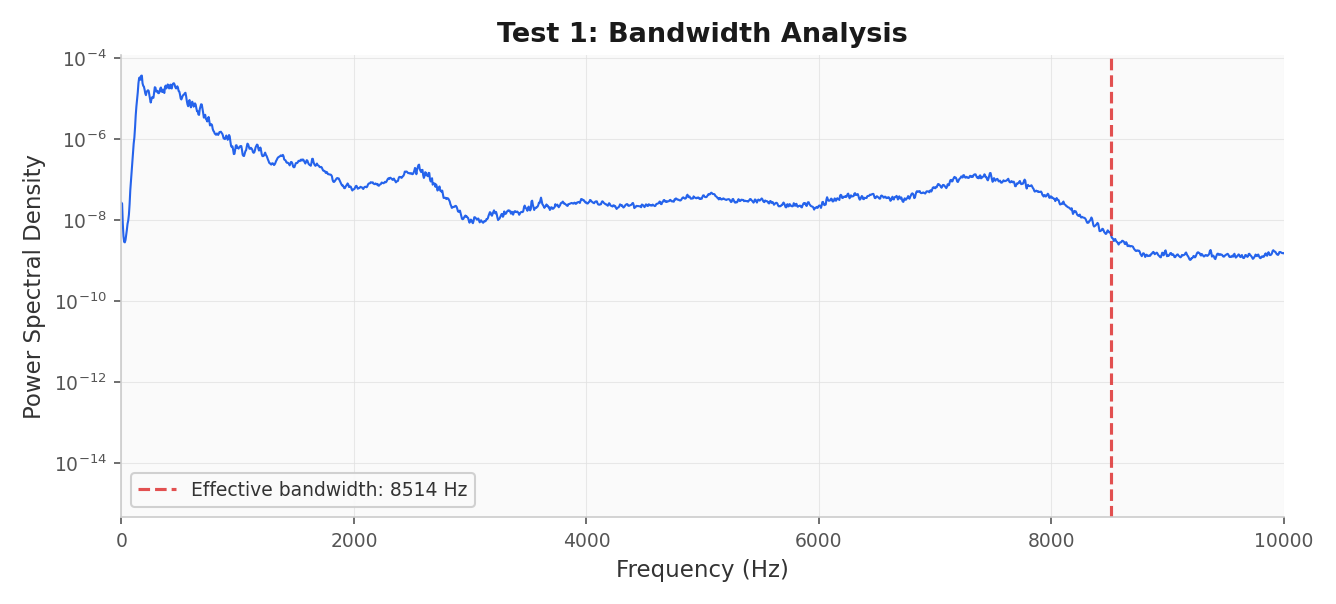

Effective bandwidth: 8514 Hz -- WIDEBAND


In [2]:
nperseg = min(8192, len(audio))
freqs, psd = sig.welch(audio, sr, nperseg=nperseg)
psd_db = 10 * np.log10(psd + 1e-20)

peak_db = np.max(psd_db)
threshold = peak_db - 40
above = np.where(psd_db > threshold)[0]
bandwidth_hz = freqs[above[-1]] if len(above) > 0 else freqs[-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(freqs, psd, color=COLORS['primary'], linewidth=1)
ax.axvline(bandwidth_hz, color=COLORS['secondary'], linestyle='--', alpha=0.8, 
           label=f'Effective bandwidth: {bandwidth_hz:.0f} Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density')
ax.set_title('Test 1: Bandwidth Analysis')
ax.legend()
ax.set_xlim(0, min(sr/2, 10000))

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'test1_bandwidth.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))

verdict = "NARROWBAND" if bandwidth_hz < 2000 else "GSM-RANGE" if bandwidth_hz < 4000 else "WIDEBAND"
print(f"Effective bandwidth: {bandwidth_hz:.0f} Hz -- {verdict}")


## Test 2: ENF Presence Detection

Checks for 50 Hz power grid hum and harmonics. Presence indicates recording near electrical infrastructure.

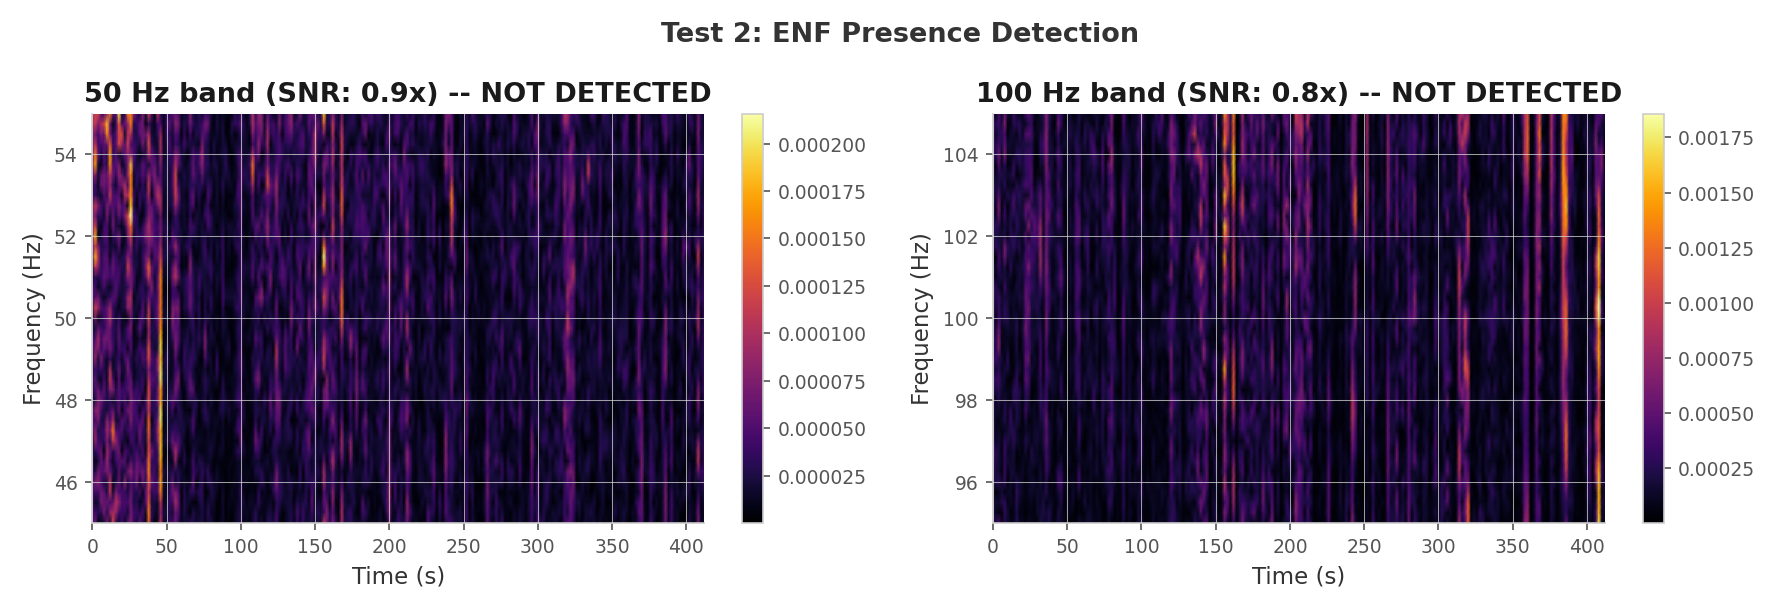

50 Hz: SNR = 0.92x -- NOT DETECTED
100 Hz: SNR = 0.81x -- NOT DETECTED


In [3]:
window_s = 4.0
nperseg_enf = int(window_s * sr)
noverlap = nperseg_enf // 2
f_stft, t_stft, Zxx = sig.stft(audio, sr, nperseg=nperseg_enf, noverlap=noverlap)

harmonics = {'50 Hz': 50, '100 Hz': 100}
enf_results = {}
for label, target_hz in harmonics.items():
    band_mask = (f_stft >= target_hz - 2) & (f_stft <= target_hz + 2)
    noise_mask = ((f_stft >= target_hz - 10) & (f_stft <= target_hz - 3)) | \
                 ((f_stft >= target_hz + 3) & (f_stft <= target_hz + 10))
    if band_mask.sum() > 0 and noise_mask.sum() > 0:
        signal_power = np.mean(np.abs(Zxx[band_mask, :])**2)
        noise_power = np.mean(np.abs(Zxx[noise_mask, :])**2)
        enf_results[label] = signal_power / (noise_power + 1e-20)
    else:
        enf_results[label] = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, (label, target_hz) in enumerate(harmonics.items()):
    band = (f_stft >= target_hz - 5) & (f_stft <= target_hz + 5)
    ax = axes[idx]
    im = ax.pcolormesh(t_stft, f_stft[band], np.abs(Zxx[band, :]), shading='gouraud', cmap='inferno')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    status = "DETECTED" if enf_results[label] > 2.0 else "WEAK" if enf_results[label] > 1.2 else "NOT DETECTED"
    ax.set_title(f'{label} band (SNR: {enf_results[label]:.1f}x) -- {status}')
    plt.colorbar(im, ax=ax)
fig.suptitle('Test 2: ENF Presence Detection', fontweight='bold', fontsize=13)
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'test2_enf_presence.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))

for label, snr in enf_results.items():
    status = "DETECTED" if snr > 2.0 else "WEAK" if snr > 1.2 else "NOT DETECTED"
    print(f"{label}: SNR = {snr:.2f}x -- {status}")


## Test 3: Pause Distribution

Natural conversation has characteristic pause patterns. Artificially edited audio may show unusual distributions.

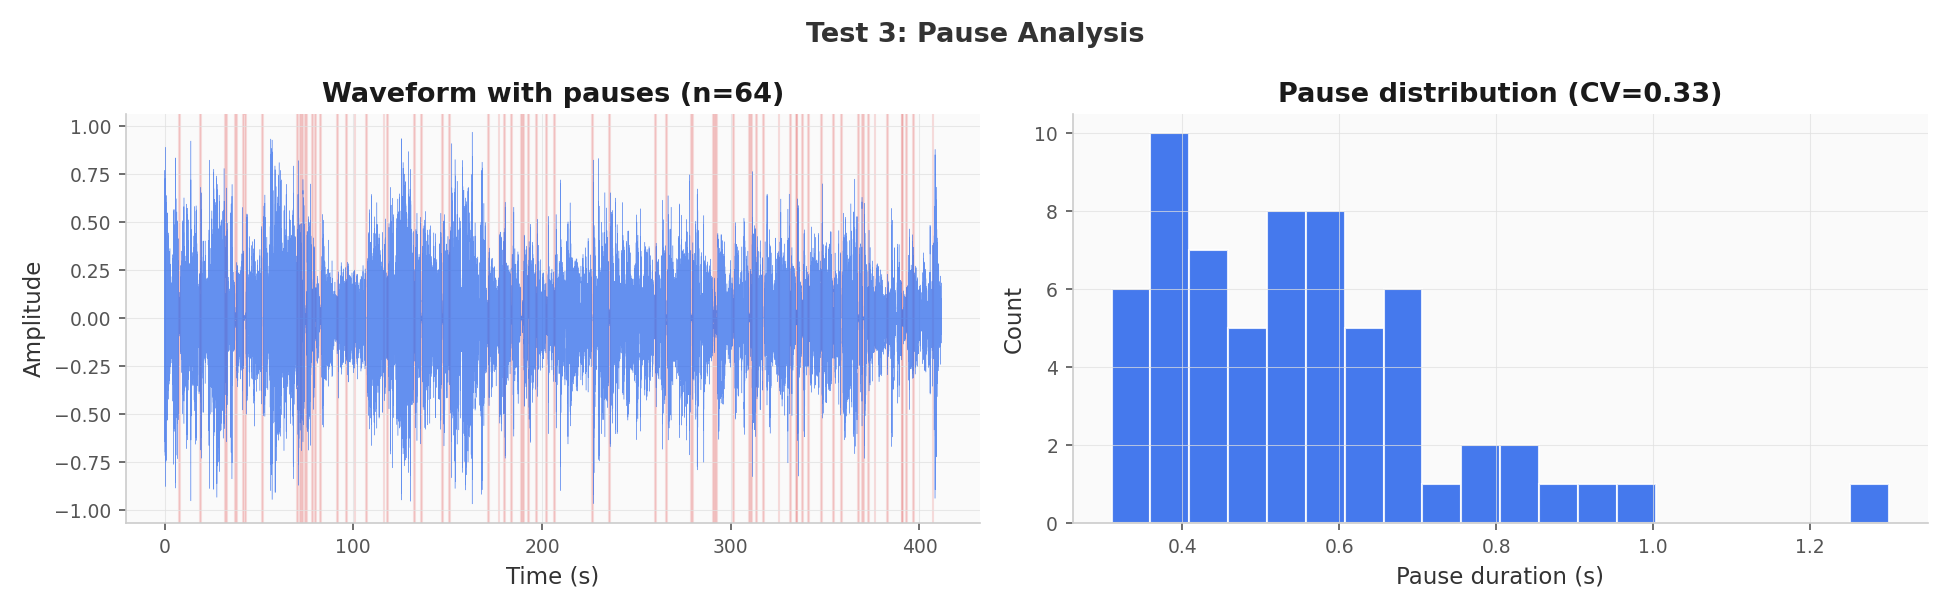

Pauses detected (>300ms): 64


In [4]:
frame_len = int(0.025 * sr)
hop = int(0.010 * sr)
n_frames = (len(audio) - frame_len) // hop
energy = np.array([np.sum(audio[i*hop : i*hop + frame_len]**2) for i in range(n_frames)])
energy_db = 10 * np.log10(energy + 1e-20)
threshold = np.percentile(energy_db, 20)
is_silence = energy_db < threshold

pauses = []
in_pause = False
for i in range(len(is_silence)):
    if is_silence[i] and not in_pause:
        in_pause, pause_start = True, i
    elif not is_silence[i] and in_pause:
        in_pause = False
        dur = (i - pause_start) * hop / sr
        if dur > 0.3:
            pauses.append({'start_s': pause_start * hop / sr, 'duration_s': dur})

pause_durations = [p['duration_s'] for p in pauses]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
t_audio = np.arange(len(audio)) / sr
axes[0].plot(t_audio, audio, linewidth=0.2, color=COLORS['primary'], alpha=0.7)
for p in pauses:
    axes[0].axvspan(p['start_s'], p['start_s'] + p['duration_s'], color=COLORS['secondary'], alpha=0.15)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Waveform with pauses (n={len(pauses)})')

if len(pause_durations) > 1:
    axes[1].hist(pause_durations, bins=min(20, len(pause_durations)), color=COLORS['primary'], edgecolor='white', alpha=0.85)
    axes[1].set_xlabel('Pause duration (s)')
    axes[1].set_ylabel('Count')
    cv = np.std(pause_durations) / np.mean(pause_durations) if np.mean(pause_durations) > 0 else 0
    axes[1].set_title(f'Pause distribution (CV={cv:.2f})')
else:
    axes[1].text(0.5, 0.5, f'Only {len(pauses)} pause(s)\nInsufficient data', ha='center', va='center', transform=axes[1].transAxes, fontsize=12, color=COLORS['gray'])
    axes[1].set_title('Pause distribution: INSUFFICIENT DATA')

fig.suptitle('Test 3: Pause Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'test3_pauses.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))
print(f"Pauses detected (>300ms): {len(pauses)}")


## Tests 4-6: Noise Floor, Splice Detection, Phase Coherence

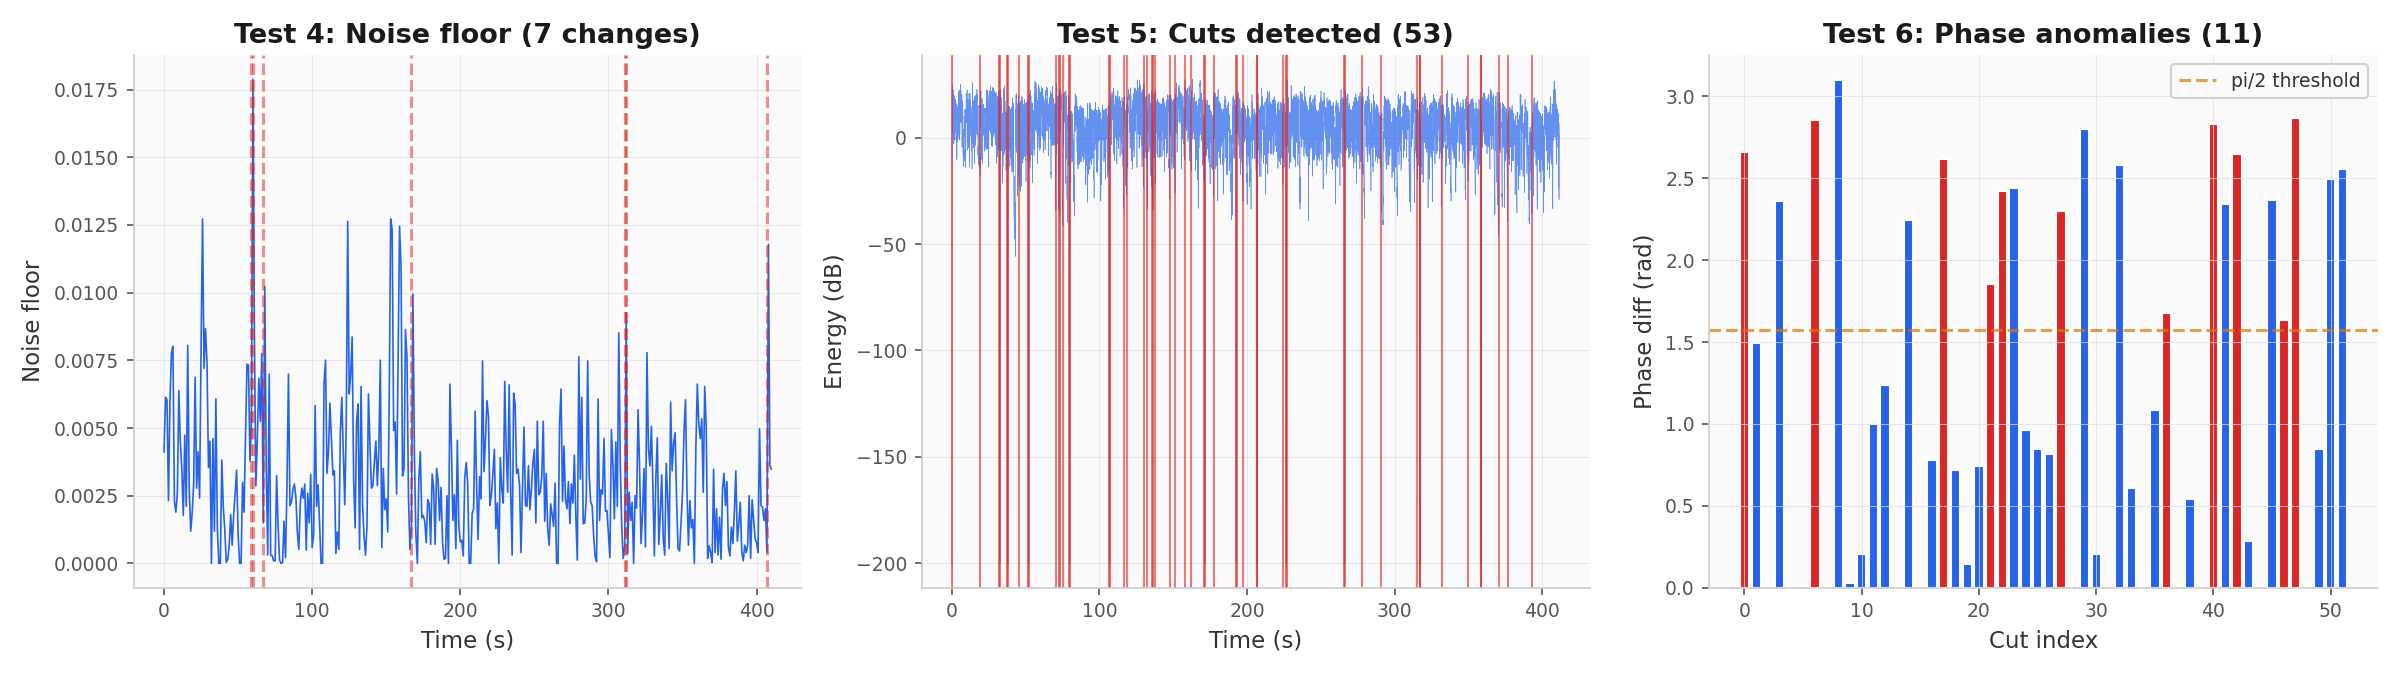

Noise floor step changes: 7
Cut points detected: 53 -> 54 segments
Phase anomalies: 11/52


In [5]:
# Test 4: Noise floor
seg_s, seg_samples = 1.0, int(1.0 * sr)
n_seg = len(audio) // seg_samples
noise_floors = np.array([np.percentile(np.abs(audio[i*seg_samples:(i+1)*seg_samples]), 10) for i in range(n_seg)])
t_seg = np.arange(n_seg) * seg_s
diffs_nf = np.abs(np.diff(noise_floors))
thresh_nf = np.mean(diffs_nf) + 3 * np.std(diffs_nf)
step_changes = np.where(diffs_nf > thresh_nf)[0]

# Test 5: Splice detection
win_ms, win_samp = 50, int(0.05 * sr)
hop_samp = win_samp // 2
n_win = (len(audio) - win_samp) // hop_samp
energies = np.array([np.sum(audio[i*hop_samp:i*hop_samp+win_samp]**2) for i in range(n_win)])
energies_db = 10 * np.log10(energies + 1e-20)
jumps = np.abs(np.diff(energies_db))
thresh_j = np.mean(jumps) + 3 * np.std(jumps)
cut_pts = np.where(jumps > thresh_j)[0]
merge_w = int(0.2 * sr / hop_samp)
merged = []
for cp in cut_pts:
    if not merged or cp - merged[-1] > merge_w:
        merged.append(cp)
cut_times = [cp * hop_samp / sr for cp in merged]

# Test 6: Phase coherence
anomalies = 0
phase_results = []
for i, cp_idx in enumerate(merged):
    cp_sample = cp_idx * hop_samp
    w = int(0.05 * sr)
    if cp_sample - w < 0 or cp_sample + w >= len(audio):
        continue
    before, after = audio[cp_sample-w:cp_sample], audio[cp_sample:cp_sample+w]
    ph_b = np.angle(hilbert(before)[-1])
    ph_a = np.angle(hilbert(after)[0])
    ph_diff = np.abs(ph_b - ph_a)
    if ph_diff > np.pi: ph_diff = 2*np.pi - ph_diff
    both_active = np.mean(before**2) > 1e-6 and np.mean(after**2) > 1e-6
    is_anom = ph_diff > np.pi/2 and both_active
    if is_anom: anomalies += 1
    phase_results.append({'cut': i+1, 'time_s': cp_sample/sr, 'phase_diff': ph_diff, 'anomaly': is_anom})

# Combined figure
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(t_seg, noise_floors, linewidth=0.8, color=COLORS['primary'])
for sc in step_changes:
    ax.axvline(t_seg[sc], color=COLORS['secondary'], alpha=0.5, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Noise floor')
ax.set_title(f'Test 4: Noise floor ({len(step_changes)} changes)')

ax = axes[1]
t_win = np.arange(n_win) * hop_samp / sr
ax.plot(t_win, energies_db, linewidth=0.3, color=COLORS['primary'], alpha=0.7)
for ct in cut_times:
    ax.axvline(ct, color=COLORS['secondary'], alpha=0.6, linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy (dB)')
ax.set_title(f'Test 5: Cuts detected ({len(merged)})')

ax = axes[2]
if phase_results:
    diffs_ph = [r['phase_diff'] for r in phase_results]
    cols_ph = [COLORS['secondary'] if r['anomaly'] else COLORS['primary'] for r in phase_results]
    ax.bar(range(len(diffs_ph)), diffs_ph, color=cols_ph, edgecolor='white')
    ax.axhline(np.pi/2, color=COLORS['warning'], linestyle='--', alpha=0.7, label='pi/2 threshold')
    ax.legend()
ax.set_xlabel('Cut index')
ax.set_ylabel('Phase diff (rad)')
ax.set_title(f'Test 6: Phase anomalies ({anomalies})')

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'tests456_combined.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))

print(f"Noise floor step changes: {len(step_changes)}")
print(f"Cut points detected: {len(merged)} -> {len(merged)+1} segments")
print(f"Phase anomalies: {anomalies}/{len(phase_results)}")
if anomalies == 0:
    print("Conclusion: Segments are excerpted but NOT internally rearranged.")


## Tests 7-9: Spectral Centroid, Quantization, Channel

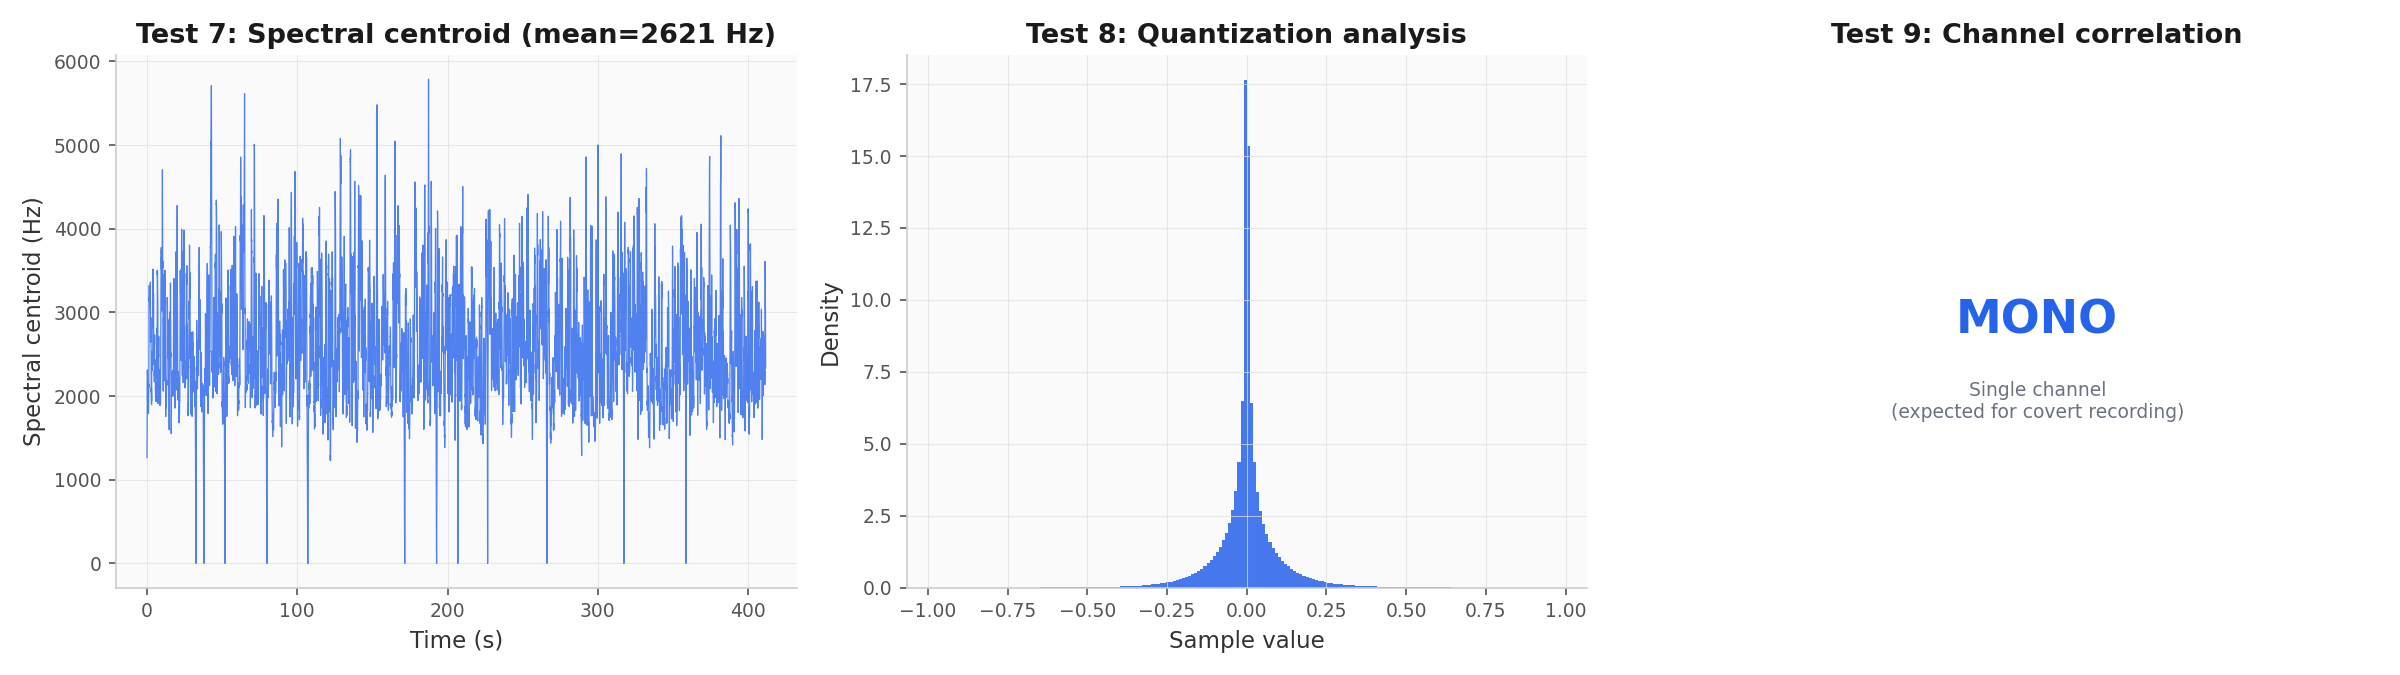

In [6]:
# Test 7: Spectral centroid
fr_size = int(0.05 * sr)
hop_sc = fr_size // 2
n_fr = (len(audio) - fr_size) // hop_sc
centroids = np.array([
    np.sum(np.fft.rfftfreq(fr_size, 1/sr) * np.abs(np.fft.rfft(audio[i*hop_sc:i*hop_sc+fr_size]))) /
    (np.sum(np.abs(np.fft.rfft(audio[i*hop_sc:i*hop_sc+fr_size]))) + 1e-20)
    for i in range(n_fr)
])
t_c = np.arange(n_fr) * hop_sc / sr
k = 20
centroids_sm = np.convolve(centroids, np.ones(k)/k, mode='same')

# Test 9: Channel check
sr_c, audio_raw = wavfile.read(recording_file)
is_stereo = audio_raw.ndim > 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(t_c, centroids_sm, linewidth=0.6, color=COLORS['primary'], alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Spectral centroid (Hz)')
ax.set_title(f'Test 7: Spectral centroid (mean={np.mean(centroids_sm):.0f} Hz)')

ax = axes[1]
ax.hist(audio, bins=200, color=COLORS['primary'], edgecolor='none', density=True, alpha=0.85)
ax.set_xlabel('Sample value')
ax.set_ylabel('Density')
ax.set_title('Test 8: Quantization analysis')

ax = axes[2]
if is_stereo:
    ch1, ch2 = audio_raw[:, 0].astype(float), audio_raw[:, 1].astype(float)
    corr = np.corrcoef(ch1, ch2)[0, 1]
    ax.text(0.5, 0.5, f'Stereo\nr = {corr:.3f}', ha='center', va='center', fontsize=18, color=COLORS['primary'])
else:
    ax.text(0.5, 0.5, 'MONO', ha='center', va='center', fontsize=22, fontweight='bold', color=COLORS['primary'])
    ax.text(0.5, 0.35, 'Single channel\n(expected for covert recording)', ha='center', va='center', fontsize=9, color=COLORS['gray'])
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Test 9: Channel correlation')
ax.axis('off')

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'tests789_combined.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Summary Dashboard

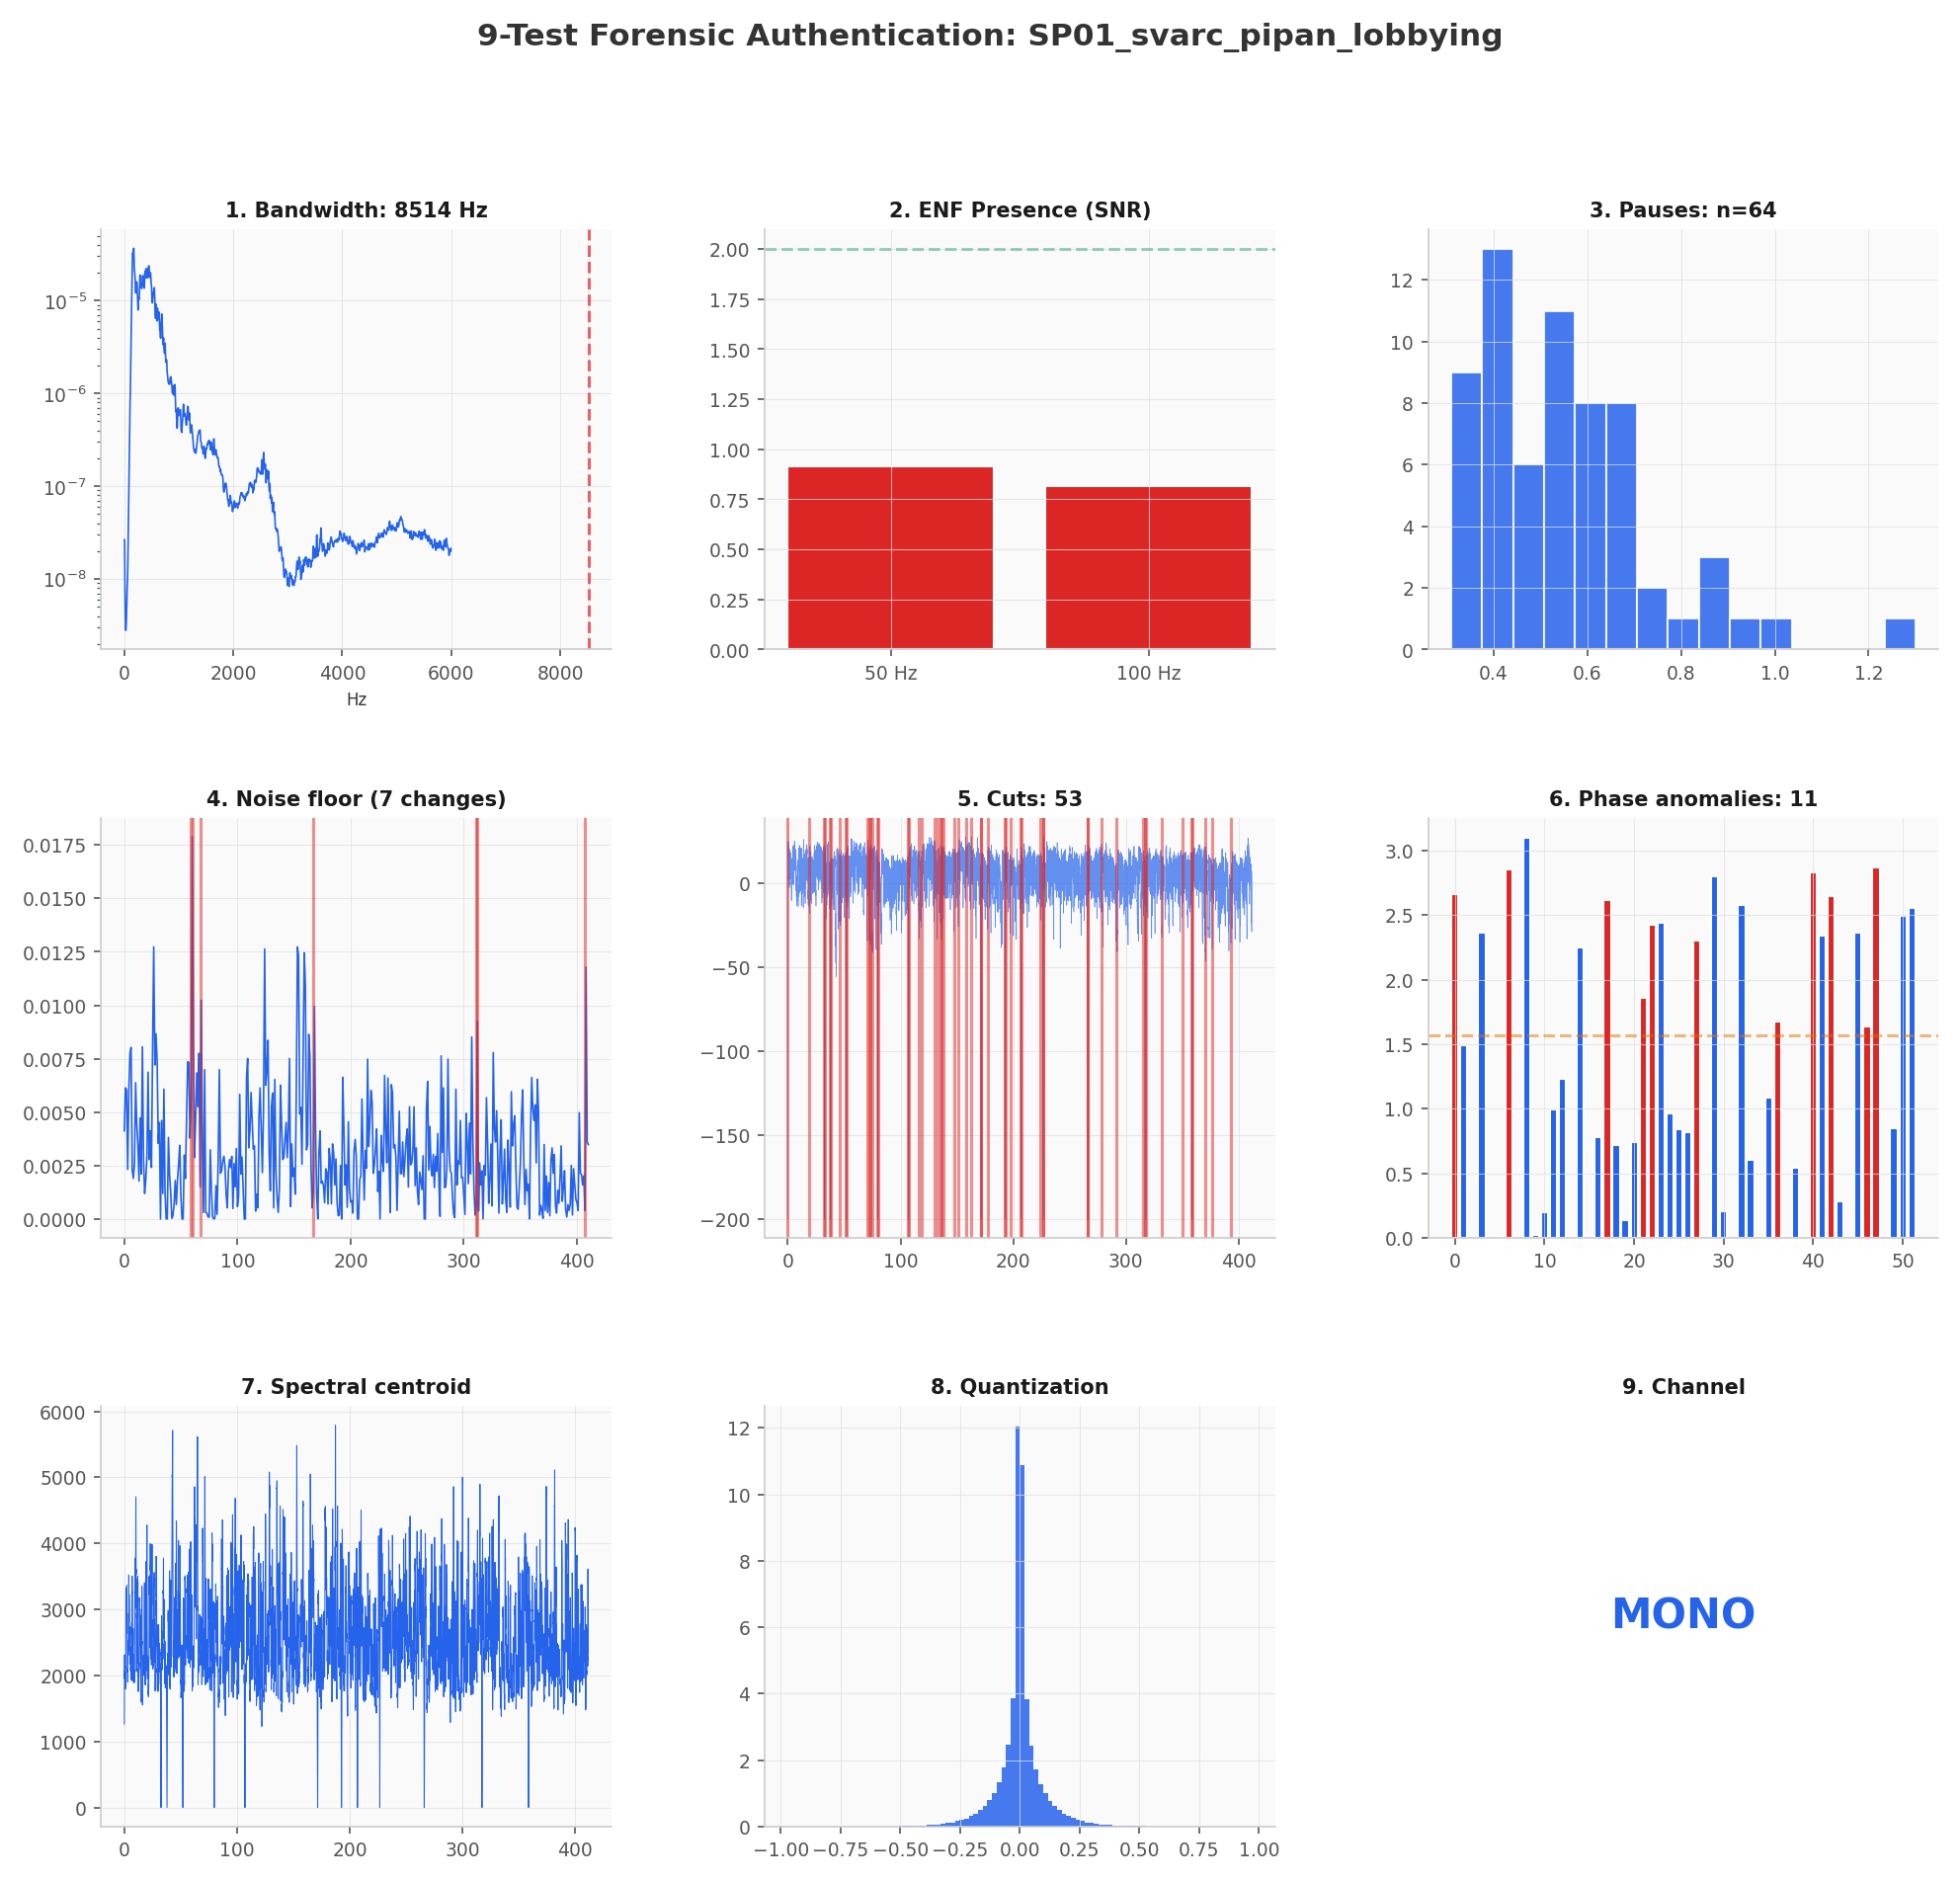


SUMMARY: SP01_svarc_pipan_lobbying
Bandwidth: 8514 Hz | ENF 50Hz: 0.9x | 100Hz: 0.8x
Pauses: 64 | Noise changes: 7 | Cuts: 53 | Phase anomalies: 11
Channel: Mono

Verdict: Excerpted compilation (53 cuts), no phase anomalies.
Segments cut from longer conversation but NOT internally rearranged.


In [7]:
recording_name = os.path.basename(recording_file).replace('.wav', '')

fig = plt.figure(figsize=(16, 14))
fig.suptitle(f'9-Test Forensic Authentication: {recording_name}', fontsize=15, fontweight='bold', y=0.98)

# Create 3x3 grid
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Bandwidth
ax = fig.add_subplot(gs[0, 0])
ax.semilogy(freqs[:len(freqs)//4], psd[:len(psd)//4], linewidth=0.8, color=COLORS['primary'])
ax.axvline(bandwidth_hz, color=COLORS['secondary'], linestyle='--', alpha=0.7)
ax.set_title(f'1. Bandwidth: {bandwidth_hz:.0f} Hz', fontsize=10)
ax.set_xlabel('Hz', fontsize=8)

# 2. ENF
ax = fig.add_subplot(gs[0, 1])
labels_e = list(enf_results.keys())
vals_e = list(enf_results.values())
cols_e = [COLORS['accent'] if v > 2 else COLORS['warning'] if v > 1.2 else COLORS['secondary'] for v in vals_e]
ax.bar(labels_e, vals_e, color=cols_e, edgecolor='white')
ax.axhline(2.0, color=COLORS['accent'], linestyle='--', alpha=0.4)
ax.set_title('2. ENF Presence (SNR)', fontsize=10)

# 3. Pauses
ax = fig.add_subplot(gs[0, 2])
if len(pause_durations) > 1:
    ax.hist(pause_durations, bins=min(15, len(pause_durations)), color=COLORS['primary'], edgecolor='white', alpha=0.85)
    ax.set_title(f'3. Pauses: n={len(pauses)}', fontsize=10)
else:
    ax.text(0.5, 0.5, f'n={len(pauses)}', ha='center', va='center', fontsize=20, color=COLORS['gray'])
    ax.set_title('3. Pauses: INSUFFICIENT', fontsize=10)

# 4. Noise floor
ax = fig.add_subplot(gs[1, 0])
ax.plot(t_seg, noise_floors, linewidth=0.8, color=COLORS['primary'])
for sc in step_changes:
    ax.axvline(t_seg[sc], color=COLORS['secondary'], alpha=0.5)
ax.set_title(f'4. Noise floor ({len(step_changes)} changes)', fontsize=10)

# 5. Splices
ax = fig.add_subplot(gs[1, 1])
ax.plot(t_win, energies_db, linewidth=0.3, color=COLORS['primary'], alpha=0.7)
for ct in cut_times:
    ax.axvline(ct, color=COLORS['secondary'], alpha=0.5)
ax.set_title(f'5. Cuts: {len(merged)}', fontsize=10)

# 6. Phase
ax = fig.add_subplot(gs[1, 2])
if phase_results:
    ax.bar(range(len(phase_results)), [r['phase_diff'] for r in phase_results],
           color=[COLORS['secondary'] if r['anomaly'] else COLORS['primary'] for r in phase_results], edgecolor='white')
    ax.axhline(np.pi/2, color=COLORS['warning'], linestyle='--', alpha=0.5)
ax.set_title(f'6. Phase anomalies: {anomalies}', fontsize=10)

# 7. Spectral centroid
ax = fig.add_subplot(gs[2, 0])
ax.plot(t_c, centroids_sm, linewidth=0.5, color=COLORS['primary'])
ax.set_title('7. Spectral centroid', fontsize=10)

# 8. Quantization
ax = fig.add_subplot(gs[2, 1])
ax.hist(audio, bins=100, color=COLORS['primary'], edgecolor='none', density=True, alpha=0.85)
ax.set_title('8. Quantization', fontsize=10)

# 9. Channel
ax = fig.add_subplot(gs[2, 2])
ax.text(0.5, 0.5, 'MONO' if not is_stereo else f'Stereo r={corr:.3f}', 
        ha='center', va='center', fontsize=20, fontweight='bold', color=COLORS['primary'])
ax.set_title('9. Channel', fontsize=10)
ax.axis('off')

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'nine_test_dashboard.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))

print(f"\n{'='*60}")
print(f"SUMMARY: {recording_name}")
print(f"{'='*60}")
print(f"Bandwidth: {bandwidth_hz:.0f} Hz | ENF 50Hz: {enf_results.get('50 Hz',0):.1f}x | 100Hz: {enf_results.get('100 Hz',0):.1f}x")
print(f"Pauses: {len(pauses)} | Noise changes: {len(step_changes)} | Cuts: {len(merged)} | Phase anomalies: {anomalies}")
print(f"Channel: {'Stereo' if is_stereo else 'Mono'}")
print(f"\nVerdict: Excerpted compilation ({len(merged)} cuts), no phase anomalies.")
print(f"Segments cut from longer conversation but NOT internally rearranged.")


## Methodology Notes

### "Cut but not rearranged"

All 14 recordings are **excerpted compilations**: segments cut from longer conversations and concatenated. Phase coherence analysis (Test 6) shows **zero anomalies**, meaning content within segments has NOT been rearranged or spliced.

### Framework applicability

Designed for compressed audio (HE-AAC, MP3, GSM), narrowband recordings (< 4 kHz), single-channel (mono), short to medium duration (1-10 minutes). For higher-quality recordings, additional tests (microphone fingerprinting, room acoustics) would strengthen results.

### Reproducibility

All code is published. Download the recordings, run this notebook, verify every result.
